<a href="https://colab.research.google.com/github/gerdoc-unir/M1-ACT-1/blob/Todo/Actividad1_MODAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from typing import AnyStr, List
import os
from pathlib import Path
import shutil
import random
import tensorflow as tf

from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
# Importando layers de keras
from tensorflow.keras import layers

In [ ]:
!rm -fr images

In [ ]:
#Declaración de variables
path_img_tar: AnyStr = 'images.tar.gz'
path_annotations_tar: AnyStr = 'annotations.tar.gz'
path_img: AnyStr = 'images'
path_annotations: AnyStr = 'annotations'
cat_label: AnyStr = 'cat'
dog_label: AnyStr = 'dog'
train_label: AnyStr = 'train'
validation_label: AnyStr = 'validation'
test_label: AnyStr = 'test'
total_label: AnyStr = 'total'
conjunto_label: AnyStr = "Conjunto"
carpeta_img: Path = None
archivos: List = None
carpeta_train: Path = None
carpeta_validation: Path = None
carpeta_test: Path = None
archivos_gatos: List = None
archivos_perros: List = None
proporciones: List[float] = [0.8, 0.1, 0.1]
gatos_train:List = []
gatos_validation:List = []
gatos_test: List = []
perros_train:List = []
perros_validation:List = []
perros_test: List = []
IMG_HEIGHT = 160
IMG_WIDTH = 160
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32

In [ ]:
#Validamos la separación sea correcta
assert abs(sum(proporciones) - 1.0) < 1e-9

In [ ]:
#Descargando images
if not os.path.exists( path_img_tar ):
  print('Descargando imagenes...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_img_tar}')

#Descargando anotaciones
if not os.path.exists( path_annotations_tar ):
  print('Descargando anotaciones...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_annotations_tar}')

#Descompactando images
if os.path.exists( path_img_tar ) and not os.path.exists( path_img ):
  print('Descompactando imagenes...')
  os.system(f'tar -xf {path_img_tar}')
  carpeta_img: Path = Path( path_img )

#Descompactando anotaciones
if os.path.exists( path_annotations_tar ) and not os.path.exists( path_annotations ):
  print('Descompactando anotaciones...')
  os.system(f'tar -xf {path_annotations_tar}')


Descompactando imagenes...


In [ ]:
#Creación de carpetas
print('Creando carpetas de perros y gatos...')
if carpeta_img:
  archivos = list( carpeta_img.glob( "*.jpg" ) )
  print(f'Imagenes: {len(archivos)}' )
  carpeta_train = Path( f'{carpeta_img}/{train_label}' )
  carpeta_validation = Path( f'{carpeta_img}/{validation_label}' )
  carpeta_test = Path( f'{carpeta_img}/{test_label}' )
  carpetas: List[AnyStr] = [carpeta_train, carpeta_validation, carpeta_test]
  for carpeta in carpetas:
    if not os.path.exists( carpeta ):
      os.mkdir( carpeta )
      print( f'Creando {carpeta}' )
      os.mkdir( f'{carpeta}/{cat_label}' )
      print( f'Creando {carpeta}/{cat_label}' )
      os.mkdir( f'{carpeta}/{dog_label}' )
      print( f'Creando {carpeta}/{dog_label}' )

  if len( archivos ) > 0:
    archivos_gatos = []
    archivos_perros = []
    for archivo in archivos:
      if archivo.name[ 0 ].isupper( ):
        archivos_gatos.append( archivo )
      else:
        archivos_perros.append( archivo )
  if len( archivos_gatos ) > 0:
    print(f'Gatos: {len(archivos_gatos)}')
  if len( archivos_perros ) > 0:
    print(f'Perros: {len(archivos_perros)}')



Creando carpetas de perros y gatos...
Imagenes: 7390
Creando images/train
Creando images/train/cat
Creando images/train/dog
Creando images/validation
Creando images/validation/cat
Creando images/validation/dog
Creando images/test
Creando images/test/cat
Creando images/test/dog
Gatos: 2400
Perros: 4990


In [ ]:
#Hacemos que se revuelvean los datos
random.seed( 42 )
random.shuffle( archivos_gatos )
random.shuffle( archivos_perros )

In [ ]:
#Separamos los archivos en los distintos dataset
def dividir_archivos(archivos: List, proporciones: List[float]):
    total:int = len( archivos )
    limite_train:int = int(total * proporciones[0])
    limite_validation:int = limite_train + int(total * proporciones[1])
    train:List = archivos[:limite_train]
    validation: List = archivos[limite_train:limite_validation]
    test: List = archivos[limite_validation:]
    return train, validation, test

In [ ]:
#Dataset de los archivos
gatos_train, gatos_validation, gatos_test = dividir_archivos( archivos_gatos, proporciones )
perros_train, perros_validation, perros_test = dividir_archivos( archivos_perros, proporciones )

In [ ]:
#Movemos los archivos a las carpetas de los dataset
def mover_archivos(archivos:List, destino: AnyStr):
    for archivo in archivos:
        shutil.move( archivo, f'{destino}/{archivo.name}' )

In [ ]:
#movemos los archivos a la estructura de la carpeta
mover_archivos( gatos_train, f'{carpeta_train}/{cat_label}' )
mover_archivos( perros_train, f'{carpeta_train}/{dog_label}')
mover_archivos( gatos_validation, f'{carpeta_validation}/{cat_label}')
mover_archivos( perros_validation, f'{carpeta_validation}/{dog_label}' )
mover_archivos( gatos_test, f'{carpeta_test}/{cat_label}' )
mover_archivos( perros_test, f'{carpeta_test}/{dog_label}' )

## Análisis exploratorio de los datos utilizados


In [ ]:
datos: List[ object ] = [
    {conjunto_label: train_label,cat_label: len(gatos_train), dog_label: len(perros_train), total_label: len(gatos_train) + len(perros_train)},
    {conjunto_label: validation_label,cat_label: len(gatos_validation), dog_label: len(perros_validation),total_label: len(gatos_validation) + len(perros_validation)},
    {conjunto_label: test_label,cat_label: len(gatos_test), dog_label: len(perros_test),total_label: len(gatos_test) + len(perros_test)}
    ]
df = pd.DataFrame( datos )
total = pd.DataFrame( [{conjunto_label:total_label, cat_label:df[cat_label].sum(),dog_label:df[dog_label].sum(),total_label:df[total_label].sum()}])
df = pd.concat( [df, total], ignore_index=True )
df.style.format({
    cat_label: "{:,}",
    dog_label: "{:,}",
    total_label: "{:,}"
})


,Conjunto,cat,dog,total
0,train,"1,920","3,992","5,912"
1,validation,240,499,739
2,test,240,499,739
3,total,"2,400","4,990","7,390"


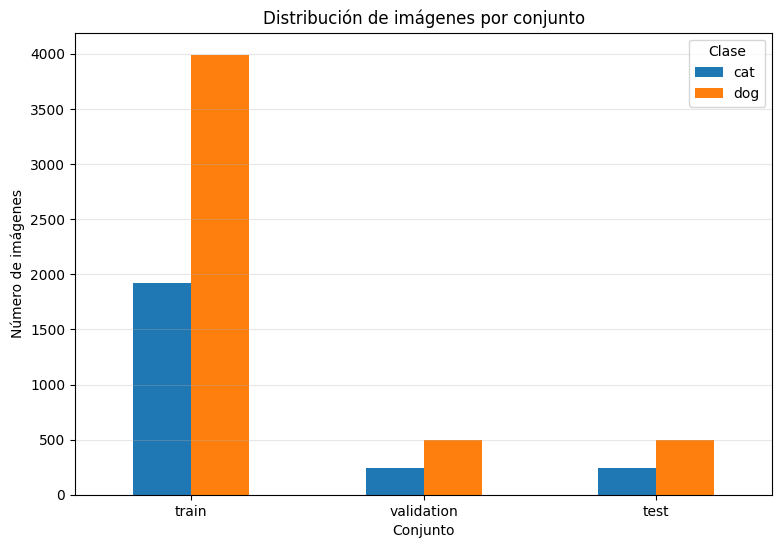

In [ ]:
df_grafica = df[df[conjunto_label] != total_label]
df_grafica.plot( x=conjunto_label, y=[cat_label, dog_label], kind="bar", figsize=(9, 6), title="Distribución de imágenes por conjunto")
plt.xlabel( conjunto_label )
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.legend( title="Clase" )
plt.grid(axis="y", alpha=0.3)
plt.show()

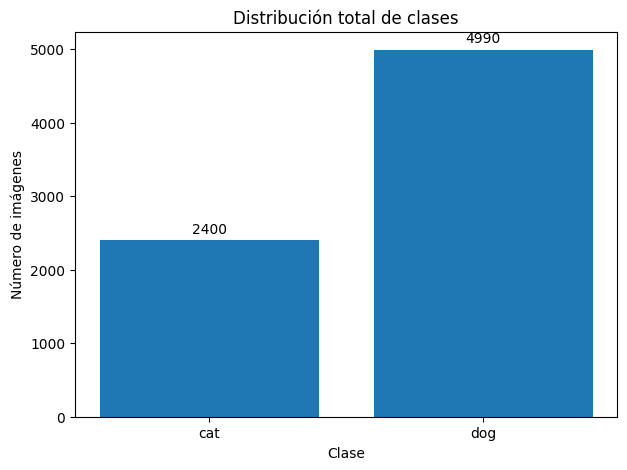

In [ ]:
totales = df[ df[ conjunto_label] == total_label]
valores = [ totales[ cat_label ].iloc[0], totales[ dog_label ].iloc[0] ]
plt.figure(figsize=(7, 5))
barras = plt.bar( [ cat_label, dog_label ], valores )
plt.title("Distribución total de clases")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.bar_label( barras, fmt="%d",padding=3 )
plt.show()

In [ ]:
gatos: int = total[ cat_label ].iloc[ 0 ]
perros: int = total[ dog_label ].iloc[ 0 ]
imagenes:int  = total[ total_label ].iloc[ 0 ]
porcentaje_gatos: float = gatos / imagenes * 100
porcentaje_perros: float = perros / imagenes * 100
print(f"Total de imágenes: {imagenes:,}")
print(f"Gatos: {gatos:,} ({porcentaje_gatos:.2f}%)")
print(f"Perros: {perros:,} ({porcentaje_perros:.2f}%)")
mayor = max(gatos, perros)
menor = min(gatos, perros)
ratio = mayor / menor
print(f"Relación de desbalance: {ratio:.2f}:1")

Total de imágenes: 7,390
Gatos: 2,400 (32.48%)
Perros: 4,990 (67.52%)
Relación de desbalance: 2.08:1


In [ ]:
#Cargamos a keras el dataset
train_ds = keras.utils.image_dataset_from_directory( carpeta_train, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
validation_ds = keras.utils.image_dataset_from_directory( carpeta_validation, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
test_ds = keras.utils.image_dataset_from_directory( carpeta_test, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
print( train_ds.class_names )

Found 5912 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
['cat', 'dog']


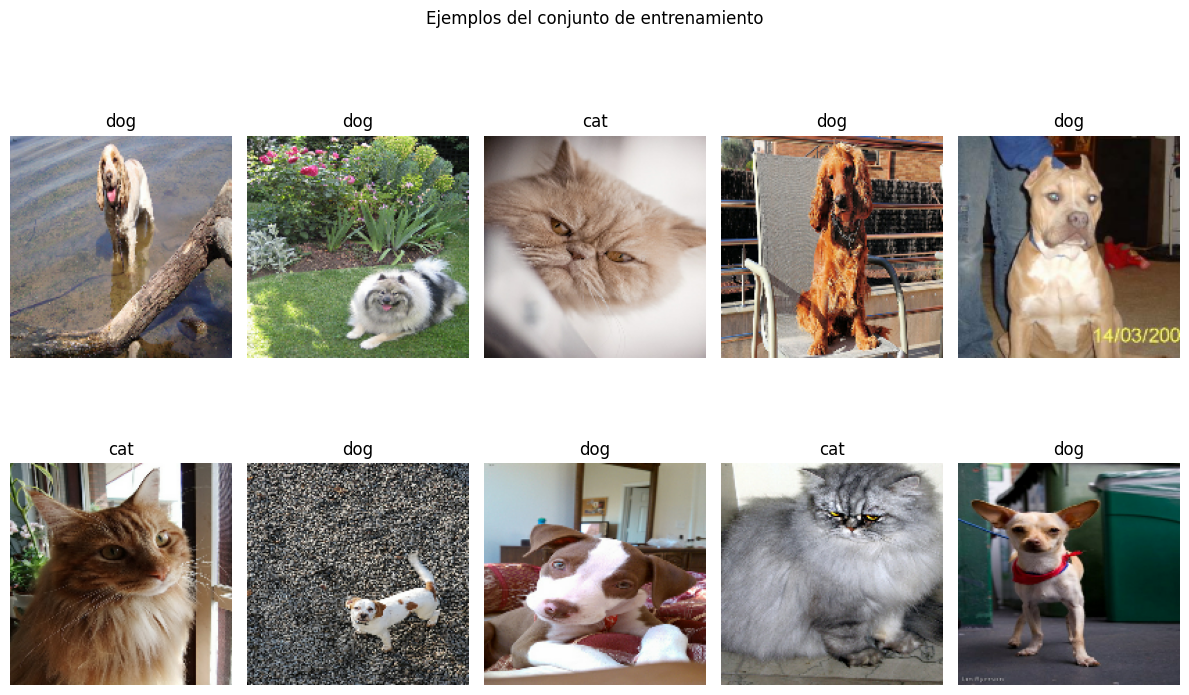

In [ ]:
plt.figure(figsize=(12, 8))
for imagenes, etiquetas in train_ds.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow( imagenes[ i ].numpy( ).astype( "uint8" ) )
        etiqueta = int( etiquetas[ i ].numpy( )[ 0 ])
        plt.title( train_ds.class_names[ etiqueta ] )
        plt.axis("off")
plt.suptitle("Ejemplos del conjunto de entrenamiento")
plt.tight_layout( )
plt.show( )

In [ ]:
#Verificamos el tamaño de las imágenes
for imagenes, etiquetas in train_ds.take( 1 ):
    print( "Imágenes:", imagenes.shape)
    print( "Etiquetas:", etiquetas.shape)

Imágenes: (32, 160, 160, 3)
Etiquetas: (32, 1)


## Conclusiones
El dataset está compuesto por un total de **7,390 imágenes**, distribuidas en dos clases:

- **Gatos:** 2,400 imágenes (**32.48 %**).
- **Perros:** 4,990 imágenes (**67.52 %**).

Las imágenes fueron divididas en tres conjuntos utilizando una proporción de **80 % para entrenamiento, 10 % para validación y 10 % para prueba**:
Se identificó un **desbalance entre las clases**, debido a que aproximadamente el **67.52 %** de las imágenes corresponden a perros y el **32.48 %** a gatos. Esto representa una relación aproximada de **2.08 imágenes de perros por cada imagen de gato**.

La inspección visual de ejemplos del conjunto de entrenamiento permitió observar imágenes con diferentes razas, tamaños, posiciones, fondos e iluminación. Esta diversidad representa un reto para el modelo, ya que deberá aprender características que permitan diferenciar gatos y perros bajo diferentes condiciones.


In [ ]:
# Normalizando pixeles
normalizacion = layers.Rescaling(1.0/ 255)
train_ds = train_ds.map(lambda x, y: (normalizacion(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalizacion(x), y))

# Mejora de rendimiento
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

# Creación de Modelo
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
alpha=0.1
modelo = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512),
    layers.LeakyReLU(alpha=alpha),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Comienza entrenamiento de LeakyReLU
modelo.summary()

historial = modelo.fit(train_ds, validation_data=validation_ds, epochs=10)


In [ ]:
# Se procede a la graficación de los resultados
import matplotlib.pyplot as plt

acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Precisión")
plt.plot(epochs_range, val_acc, label="Validación de precisión")
plt.legend(loc="lower right")
plt.title("Gráfica de precisión")

plt.tight_layout()
plt.show()